In [168]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [169]:
df = pd.read_excel("SDC_Ventas.xlsx", header=None)

df.to_csv("SDC_Ventas.csv", index=False, header=False)

In [170]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 37 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       12 non-null     str   
 1   1       12 non-null     str   
 2   2       12 non-null     object
 3   3       12 non-null     object
 4   4       12 non-null     object
 5   5       12 non-null     object
 6   6       12 non-null     object
 7   7       12 non-null     object
 8   8       12 non-null     object
 9   9       12 non-null     str   
 10  10      12 non-null     object
 11  11      12 non-null     object
 12  12      12 non-null     object
 13  13      12 non-null     object
 14  14      12 non-null     object
 15  15      12 non-null     object
 16  16      12 non-null     str   
 17  17      12 non-null     object
 18  18      12 non-null     object
 19  19      12 non-null     object
 20  20      12 non-null     object
 21  21      12 non-null     object
 22  22      12 non-null     str   
 23  23 

In [171]:
# Dejar la primera fila como encabezado y eliminar las filas vacías
df.columns = df.iloc[1]
df = df.iloc[2:].reset_index(drop=True)
df.columns.name = None
df = df.iloc[0:7, 0:32]


In [172]:
# Sacar lo de los meses
periodos = df.columns[1:].tolist()
periodos

['Enero, 24',
 'Febrero, 24',
 'Marzo, 24',
 'Abril, 24',
 'Mayo, 24',
 'Junio, 24',
 'Julio, 24',
 'Agosto, 24',
 'Septiembre, 24',
 'Octubre, 24',
 'Noviembre, 24',
 'Diciembre, 25',
 'Enero, 25',
 'Febrero, 25',
 'Marzo, 25',
 'Abril, 25',
 'Mayo, 25',
 'Junio, 25',
 'Julio, 25',
 'Agosto, 25',
 'Septiembre, 25',
 'Octubre, 25',
 'Noviembre, 25',
 'Diciembre, 25',
 'Enero, 26',
 'Febrero, 26',
 'Marzo, 26',
 'Abril, 26',
 'Mayo,26',
 'Junio, 26',
 'Julio,26']

In [173]:
cols = df.columns.tolist()
cols[12] = 'Diciembre, 24'
df.columns = cols

In [174]:
# Transponer columnas y filas
df = df.set_index('Indicador').T
df['Periodo'] = periodos
df = df.reset_index(drop=True)

# Espacios en nombres de columnas
df.columns = df.columns.str.strip()

In [175]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 31 entries, 0 to 30
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Generadas           31 non-null     object
 1   Aprobadas           31 non-null     object
 2   Condicionadas       31 non-null     object
 3   Rechazadas          31 non-null     object
 4   Formalizadas        31 non-null     object
 5   % de Aprobación     31 non-null     object
 6   % de Formalizacion  31 non-null     object
 7   Periodo             31 non-null     str   
dtypes: object(7), str(1)
memory usage: 2.1+ KB


In [176]:
num = ["Generadas", "Aprobadas", "Condicionadas", "Rechazadas", "Formalizadas", "% de Aprobación", "% de Formalizacion"]
df[num] = df[num].apply(pd.to_numeric, errors='coerce')

In [177]:
df.to_csv("SDC_ventas_limpio.csv", index=False)

In [178]:
df2 = df[["Generadas", "Aprobadas", "Condicionadas", "Rechazadas", "Formalizadas"]]

<Axes: xlabel='Generadas', ylabel='Formalizadas'>

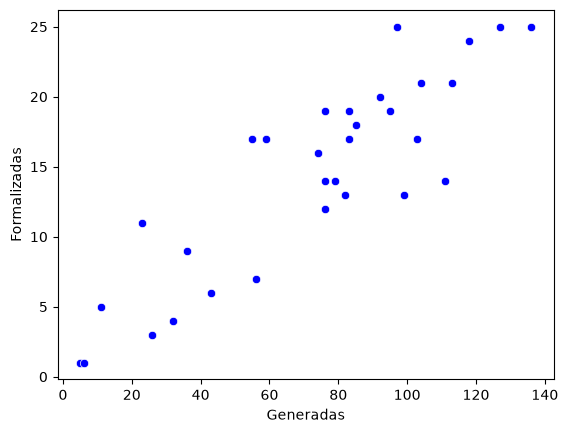

In [179]:
#Imprimimos el scatter plot entre la variable dependiente (Formalizadas) e independiente (Aprobadas) 
#para observar el comportamiento en su dispersión 
from turtle import color
sns.scatterplot(x='Generadas', y='Formalizadas', color="blue", data=df2)

In [180]:
#Declaramos las variables dependientes e independientes para la regresión lineal
Vars_Indep= df2[['Generadas']]
Var_Dep= df2['Formalizadas']

In [181]:
# Se define model como la función de regresión lineal
from sklearn.linear_model import LinearRegression
model= LinearRegression()

In [182]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=Vars_Indep, y=Var_Dep)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.17]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Generadas']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.73
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [183]:
# Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'tol': 1e-06,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['Generadas'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([0.17397778]),
 'rank_': np.int64(1),
 'singular_': array([197.04281506]),
 'intercept_': np.float64(1.7302015117954284)}

In [184]:
# Modelo matemático:
# y= 0.17397778(Generadas)+1.7302015117954284

In [185]:
#Evaluamos la eficiencia del modelo obtenido por medio del coeficiente R Determinación
model.score(Vars_Indep,Var_Dep)

0.7754234907502584

In [186]:
#Predecimos los valores de formalizado a partir de la variable "Generadas"
y_pred= model.predict(X=df2[['Generadas']])
y_pred

array([ 2.6000904 ,  2.77406817,  3.64395706,  5.73169038,  6.25362371,
        9.21124591, 11.29897923,  7.99340147, 11.47295701, 15.47444587,
       14.95251254, 19.64991251, 16.17035698, 14.95251254, 17.73615697,
       11.99489034, 14.95251254, 18.60604585, 19.82389029, 18.95400141,
       23.82537915, 25.39117914, 22.25957916, 21.04173473, 21.38969028,
       16.17035698, 16.51831253, 14.60455699, 18.2580903 , 15.9963792 ,
        7.29749037])

In [187]:
# Insertamos la columna de predicciones en el DataFrame
df2.insert(4, 'Predicciones', y_pred)
df2

Indicador,Generadas,Aprobadas,Condicionadas,Rechazadas,Predicciones,Formalizadas
0,5,1,0,4,2.600090,1
1,6,2,0,4,2.774068,1
2,11,7,1,4,3.643957,5
3,23,14,0,9,5.731690,11
4,26,8,4,14,6.253624,3
5,43,13,0,22,9.211246,6
6,55,30,3,17,11.298979,17
7,36,19,0,13,7.993401,9
8,56,26,1,13,11.472957,7
9,79,31,32,12,15.474446,14


<Axes: xlabel='Generadas', ylabel='Formalizadas'>

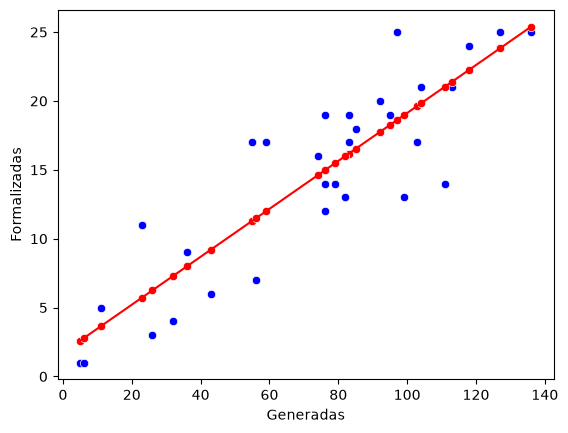

In [188]:
#Visualizamos la gráfica comparativa
sns.scatterplot(x='Generadas', y='Formalizadas', color="blue", data=df2)
sns.scatterplot(x='Generadas', y='Predicciones', color="red", data=df2)
sns.lineplot(x='Generadas', y='Predicciones', color="red", data=df2)

In [189]:
#Corroboramos cual es el coeficiente de Determinación de nuestro modelo
coef_Deter=model.score(X=Vars_Indep, y=Var_Dep)
coef_Deter

0.7754234907502584

In [190]:
#Corroboramos cual es el coeficiente de Correlación de nuestro modelo
coef_Correl=np.sqrt(coef_Deter)
coef_Correl

np.float64(0.8805813368169112)

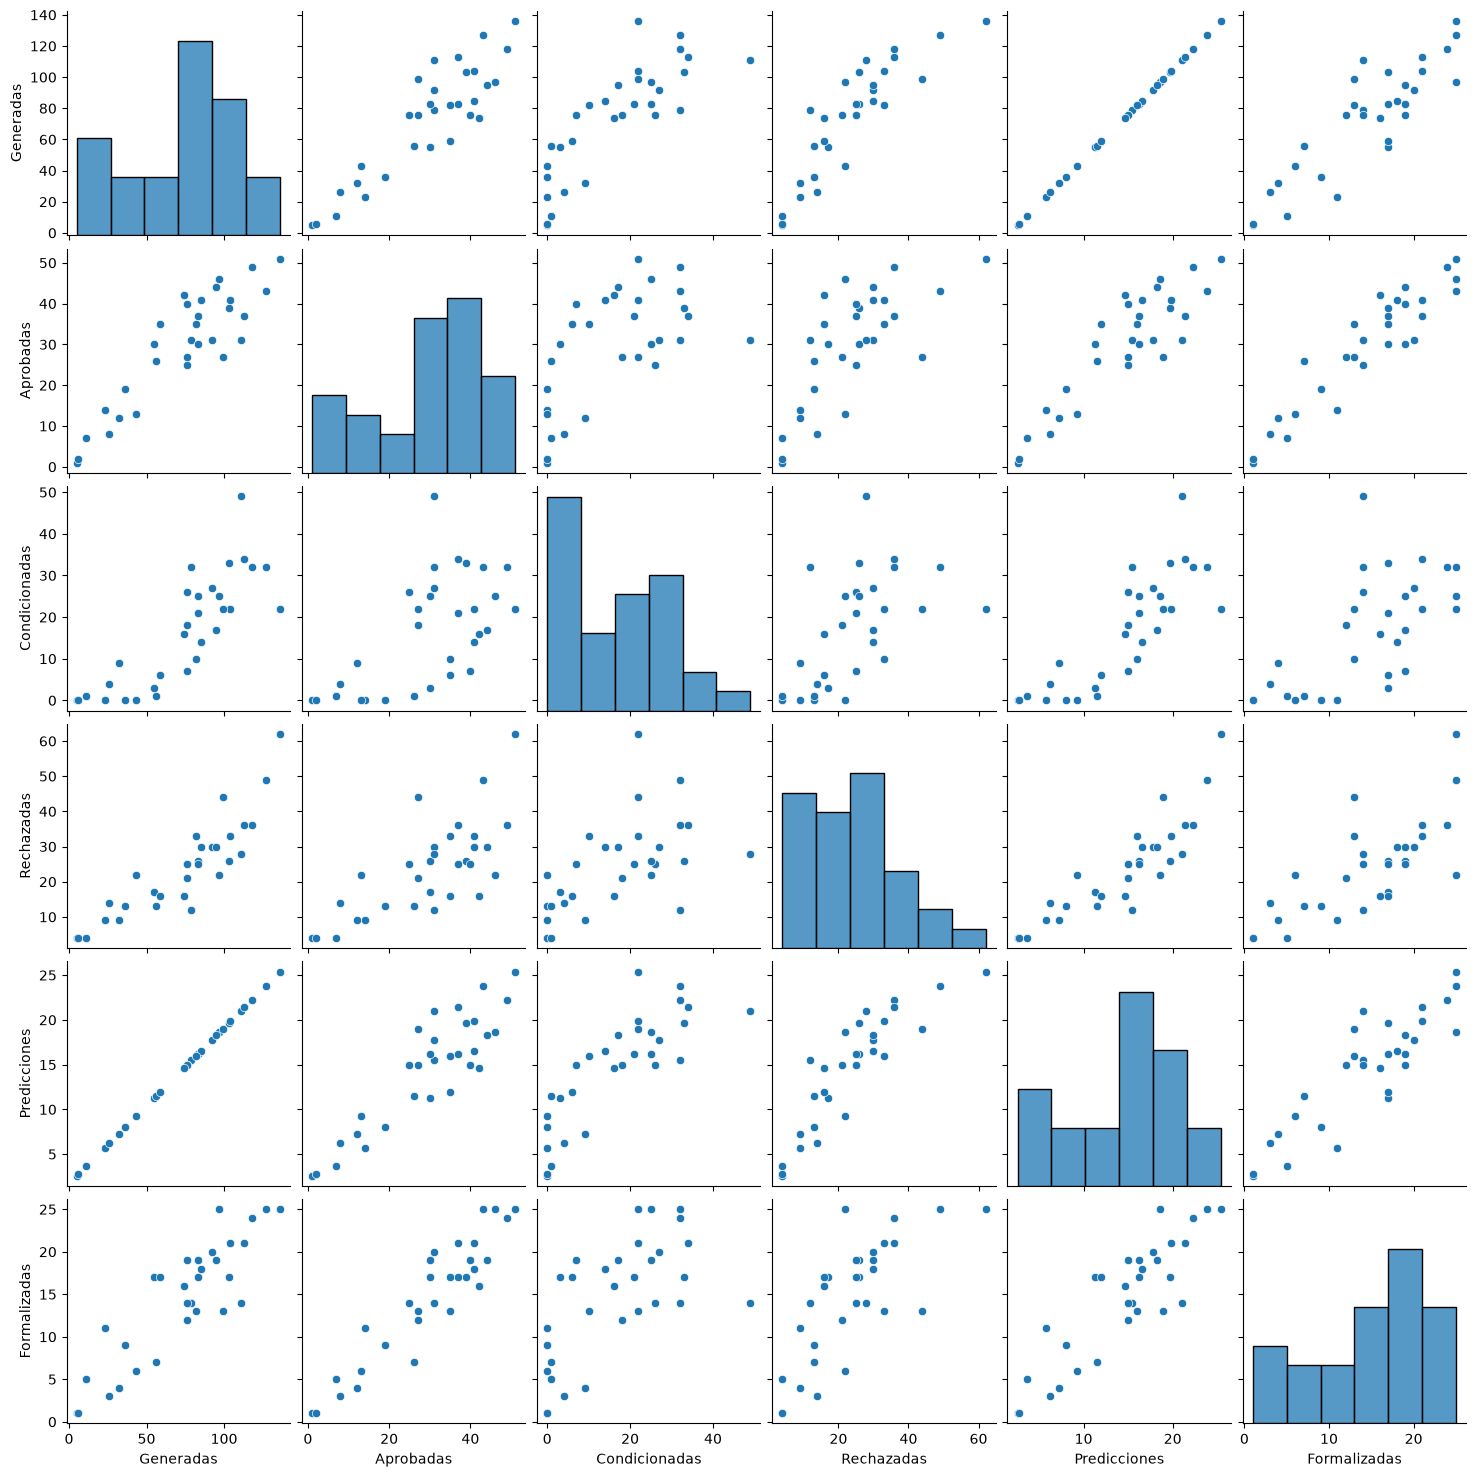

In [191]:
#Graficamos todas las dispersiones entre todas las variables, filtrado por canal
sns.pairplot(df2)

In [192]:
#Encontramos todas las correlaciones entre las variables 
Corr_Factors=df2.corr()
Corr_Factors

Indicador,Generadas,Aprobadas,Condicionadas,Rechazadas,Predicciones,Formalizadas
Indicador,,,,,,
Generadas,1.000000,0.896295,0.825762,0.881383,1.000000,0.880581
Aprobadas,0.896295,1.000000,0.609925,0.725853,0.896295,0.932941
Condicionadas,0.825762,0.609925,1.000000,0.588563,0.825762,0.647136
Rechazadas,0.881383,0.725853,0.588563,1.000000,0.881383,0.744203
Predicciones,1.000000,0.896295,0.825762,0.881383,1.000000,0.880581
Formalizadas,0.880581,0.932941,0.647136,0.744203,0.880581,1.000000


<Axes: xlabel='Indicador', ylabel='Indicador'>

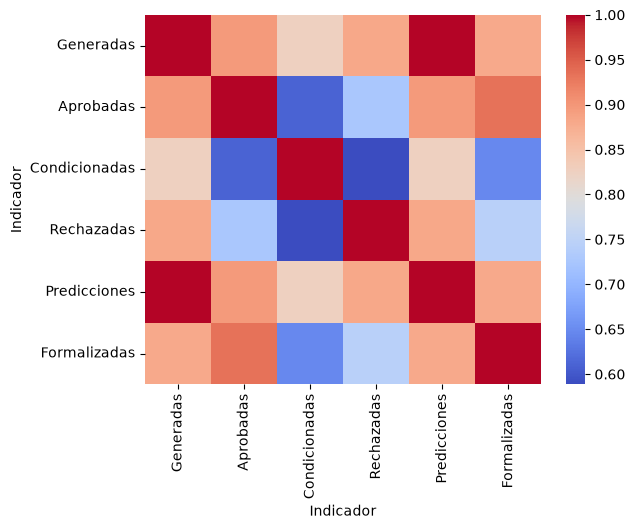

In [193]:
#Graficamos el mapa de calor de los coeficientes de correlación 
Heat_Map= sns.heatmap(Corr_Factors, cmap = 'coolwarm')  
Heat_Map

<Axes: xlabel='Indicador', ylabel='Indicador'>

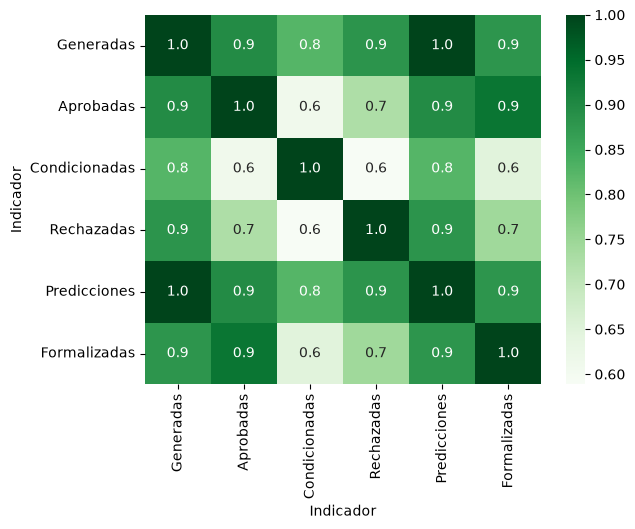

In [194]:
#Ajustamos el mapa de calor de los coeficientes de correlación 
Heat_Map= sns.heatmap(Corr_Factors, cmap = 'Greens', annot=True, fmt=".1f")  
Heat_Map